# Part II - Communicating Key Insights on U.S. Flight Delays (2011-2020)
## by Matthew Ray

## Investigation Overview

The goal of this presentation is to communicate key insights about flight delays in the United States using clear, explanatory data visualizations. Building on the exploratory analysis from Part I, this notebook focuses on identifying the most important patterns and relationships that influence arrival delays and presenting them in a concise, audience-friendly way.

This analysis examines how flight delays vary across time, airlines, and flight characteristics such as distance. Rather than exploring every possible relationship, this presentation highlights a small set of findings that best explain when and why delays tend to occur.

**Key insights from the analysis include:**
- Arrival delays are highly right-skewed, with most flights arriving on time or early and a smaller number experiencing extreme delays.
- Delays vary systematically by time-related factors such as month and day of week, indicating seasonal and operational effects.
- Some airlines exhibit consistently higher average delays than others.
- Flight distance alone does not strongly predict arrival delays, suggesting that operational factors play a larger role than flight length.

---

## Dataset Overview and Executive Summary

The dataset used in this analysis is the **Reporting Carrier On-Time Performance Data** published by the U.S. Bureau of Transportation Statistics. It contains detailed records of domestic U.S. flights, including scheduled and actual departure and arrival times, delays, cancellations, distances, and airline identifiers.

For this investigation, a subset of the most recent ten years of available data (2011–2020) was used to ensure relevance while keeping the dataset computationally manageable. After filtering and cleaning, the dataset includes approximately 600,000 flights and focuses on variables directly related to arrival delay behavior.

The explanatory visualizations that follow demonstrate that flight delays are not random. Instead, they reflect consistent patterns related to airline operations, scheduling, and seasonal demand. While no single variable fully explains delays, the combined visual evidence shows how multiple factors interact to shape overall flight performance.

In [1]:
# Import required libraries for analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visualization style for explanatory plots
sns.set_theme(style="whitegrid")

# Suppress warnings to keep final presentation output clean
import warnings
warnings.simplefilter("ignore")

In [2]:
# Load the cleaned dataset used for explanatory analysis
# This dataset was produced during Part I after filtering, cleaning,
# and selecting relevant variables for delay analysis
flights = pd.read_csv("flights_clean_10yr.csv")

# Quick check to confirm successful load
flights.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,DepDelay,CRSArrTime,ArrTime,ArrDelay,Cancelled,CancellationCode,Diverted,Distance,AirTime
0,2013,2,6,29,6,2013-06-29,MQ,GJT,DFW,1630,1644.0,14.0,1945,1942.0,-3.0,0.0,NaN,0.0,773.0,103.0
1,2019,2,6,11,2,2019-06-11,9E,ATL,CAE,1950,2331.0,221.0,2057,31.0,214.0,0.0,NaN,0.0,192.0,35.0
2,2018,1,2,8,4,2018-02-08,WN,MDW,DAL,2030,2046.0,16.0,2250,2319.0,29.0,0.0,NaN,0.0,793.0,114.0
3,2014,2,4,3,4,2014-04-03,WN,ELP,DAL,1025,1025.0,0.0,1300,1255.0,-5.0,0.0,NaN,0.0,562.0,77.0
4,2013,2,6,30,7,2013-06-30,OO,ABQ,LAX,1601,1557.0,-4.0,1705,1646.0,-19.0,0.0,NaN,0.0,677.0,95.0


## Visualization 1: Distribution of Arrival Delays

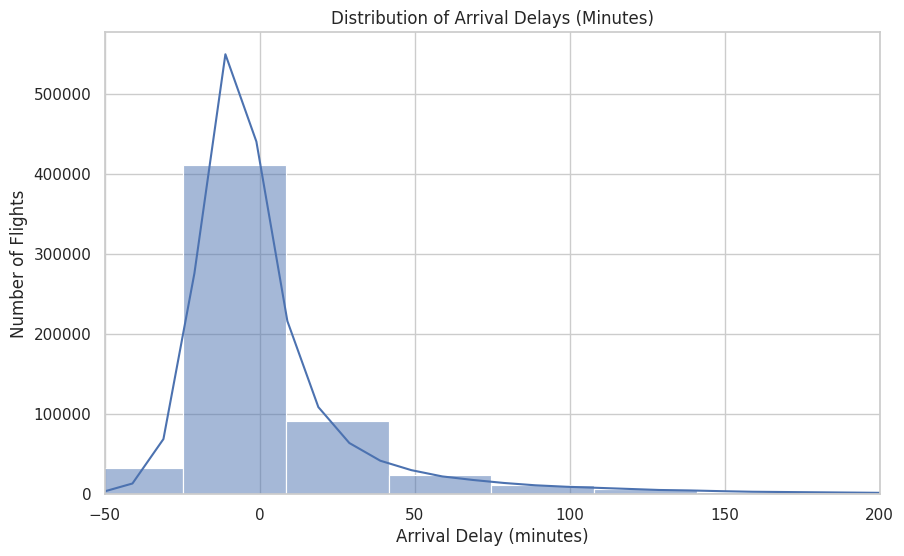

In [3]:
# Visualization 1: Distribution of Arrival Delays
# This plot shows how arrival delays are distributed across flights
# in the selected 10-year dataset. Extreme outliers are limited
# to improve readability of the main distribution.

plt.figure(figsize=(10, 6))

sns.histplot(
    flights['ArrDelay'],
    bins=60,
    kde=True
)

plt.title("Distribution of Arrival Delays (Minutes)")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")

# Limit extreme outliers for clearer interpretation
plt.xlim(-50, 200)

plt.show()

This visualization shows the distribution of arrival delays for U.S. flights over the selected 10-year period. Most flights arrive close to their scheduled arrival time, with a large concentration of values clustered near zero minutes. However, the distribution is strongly right-skewed, indicating that while severe delays are relatively rare, they can be very large when they occur.

Negative delay values (early arrivals) are present but limited in range, whereas positive delays extend much further, highlighting the operational challenges that contribute to late arrivals. To improve readability, extreme outliers were truncated at 200 minutes, allowing the main structure of the distribution to be more clearly observed.

This visualization establishes a baseline understanding of overall delay behavior and motivates further analysis into factors such as airline, distance, and scheduling patterns that may influence arrival delays.

## Visualization 2: Average Arrival Delay by Airline

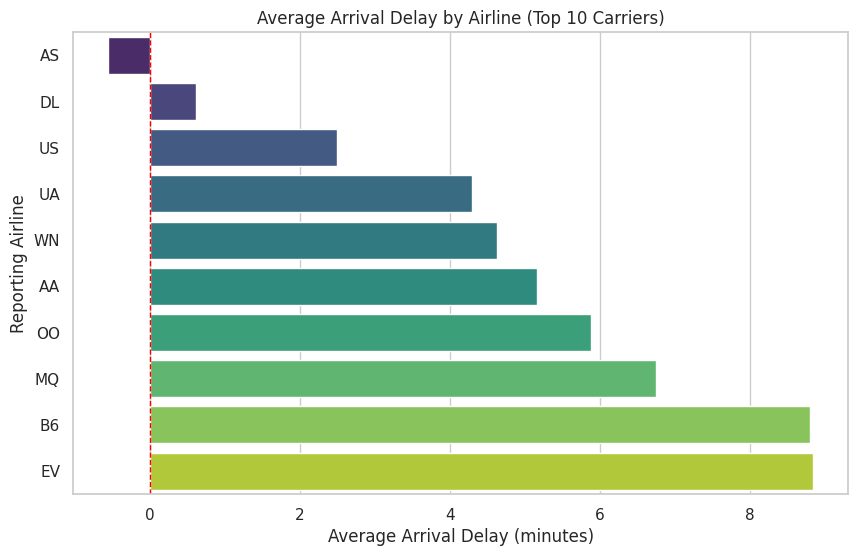

In [5]:
# Visualization 2: Average Arrival Delay by Airline (Top 10 by flight volume)

# Select top 10 airlines by number of flights to reduce clutter
top_airlines = flights['Reporting_Airline'].value_counts().head(10).index

delay_by_airline = (
    flights[flights['Reporting_Airline'].isin(top_airlines)]
    .groupby('Reporting_Airline')['ArrDelay']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=delay_by_airline.values,
    y=delay_by_airline.index,
    palette="viridis"
)

plt.title("Average Arrival Delay by Airline (Top 10 Carriers)")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Reporting Airline")
plt.axvline(0, color='red', linestyle='--', linewidth=1)  # on-time reference
plt.show()

This visualization compares the average arrival delay for the ten airlines with the highest number of flights in the dataset. A horizontal bar chart was used to make differences between carriers easy to compare.

Several airlines show positive average delays, indicating they tend to arrive late more often than early, while others cluster closer to zero, suggesting more consistent on-time performance. The dashed vertical line at zero minutes highlights the threshold between early and late arrivals.

This chart demonstrates that airline choice plays a meaningful role in arrival delay outcomes, reinforcing that delays are not evenly distributed across carriers.

## Visualization 3: Relationship Between Flight Distance and Arrival Delay

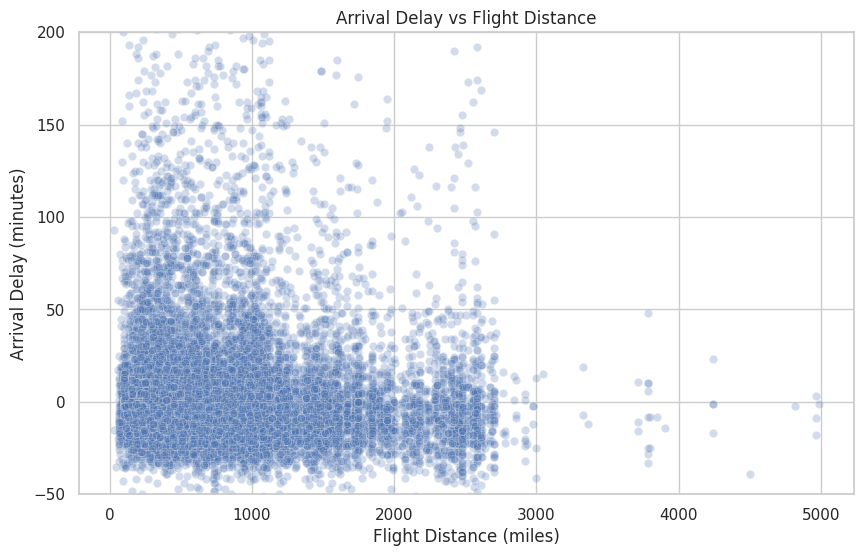

In [6]:
# Visualization 3: Flight Distance vs Arrival Delay
# Sample data to reduce overplotting while preserving trends

sample = flights.sample(20000, random_state=42)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sample,
    x="Distance",
    y="ArrDelay",
    alpha=0.25
)

plt.title("Arrival Delay vs Flight Distance")
plt.xlabel("Flight Distance (miles)")
plt.ylabel("Arrival Delay (minutes)")
plt.ylim(-50, 200)
plt.show()

This scatter plot explores how flight distance relates to arrival delays. A random sample of flights was used to reduce overplotting while preserving overall trends in the data.

Most flights, regardless of distance, arrive within a moderate delay range, but short-haul flights show a wider spread of delays, including extreme late arrivals. Longer flights tend to cluster closer to zero delay, suggesting that airlines may build more buffer time into longer routes or prioritize their operational reliability.

Overall, the visualization indicates that flight distance alone is not a strong predictor of arrival delay, but it does influence the variability of delays. This supports the broader conclusion that delays are shaped by multiple interacting factors rather than a single flight characteristic.

## Conclusion

This analysis shows that flight delays are common but highly variable, with most flights arriving close to schedule and a smaller number experiencing extreme delays. Differences in average arrival delay across airlines suggest that operational practices and scheduling strategies play a significant role in on-time performance. While flight distance affects the spread of delays, it does not strongly predict whether a flight will arrive late. Overall, arrival delays appear to result from a combination of airline behavior, scheduling buffers, and operational conditions, rather than any single flight characteristic.